In [42]:
# ─────────────────────────────────────────────────────────────
# IMPORTANT: tell Python where to find the src/ folder
# Our notebook is inside notebooks/ — src/ is one level above
# ─────────────────────────────────────────────────────────────
import sys
import os

sys.path.insert(0, os.path.abspath('..'))

print('Path set. Python will now look in:', os.path.abspath('..'))

Path set. Python will now look in: /Users/tekabe/Downloads/KAIM_WEEK1/Stock-Market-Prediction


In [43]:
# ─────────────────────────────────────────────────────────────
# Import our functions from src/
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

from src.data_loader import load_data, remove_nulls
from src.analysis    import compute_sma, get_daily_return

print('Functions imported successfully!')
print()
# You can check what a function does by calling it with ?


Functions imported successfully!



In [44]:
load_data

<function src.data_loader.load_data(filepath)>

In [45]:
# Step 1: Load the data — one line instead of six
df = load_data('../Data/AAPL.csv')
df.head()

Loaded 3774 rows from '../Data/AAPL.csv'


,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [46]:
# Step 2: Check missing values before cleaning
print('Missing values per column:')
print(df.isnull().sum())
print()

# Now remove them — one line instead of five
df = remove_nulls(df)

Missing values per column:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Removed 0 row(s). 3774 rows remaining.


In [47]:
# Step 3: Compute the 5-day Simple Moving Average
# window=5 means: average the closing price over the last 5 trading days
df['SMA_5'] = compute_sma(df['Close'], window=5)

print('5-day SMA computed. First few values are NaN (not enough history yet):')
df[['Close', 'SMA_5']].head(8).round(2)

5-day SMA computed. First few values are NaN (not enough history yet):


,Close,SMA_5
Date,,
2009-01-02,2.72,NaN
2009-01-05,2.84,NaN
2009-01-06,2.79,NaN
2009-01-07,2.73,NaN
2009-01-08,2.78,2.77
2009-01-09,2.72,2.77
2009-01-12,2.66,2.74
2009-01-13,2.63,2.70


In [48]:
# Step 4: Calculate daily return
# Formula: (today price - yesterday price) / yesterday price * 100
df['Daily_Return'] = get_daily_return(df['Close'])

print('Daily return calculated. Positive = price went up. Negative = price went down.')
df[['Close', 'Daily_Return']].round(2).head(8)

Daily return calculated. Positive = price went up. Negative = price went down.


,Close,Daily_Return
Date,,
2009-01-02,2.72,NaN
2009-01-05,2.84,4.22
2009-01-06,2.79,-1.65
2009-01-07,2.73,-2.16
2009-01-08,2.78,1.86
2009-01-09,2.72,-2.29
2009-01-12,2.66,-2.12
2009-01-13,2.63,-1.07


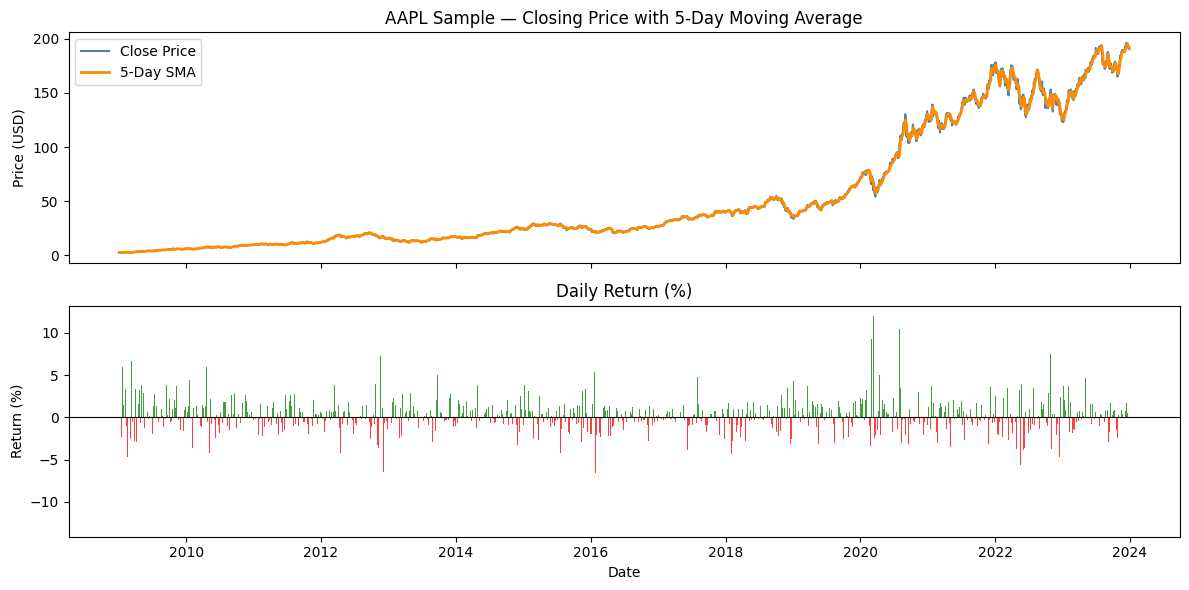

In [50]:
# Step 5: Visualise the result
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Price + moving average
ax1.plot(df.index, df['Close'],  label='Close Price', color='steelblue', linewidth=1.5)
ax1.plot(df.index, df['SMA_5'],  label='5-Day SMA',   color='darkorange', linewidth=2)
ax1.set_title('AAPL Sample — Closing Price with 5-Day Moving Average')
ax1.set_ylabel('Price (USD)')
ax1.legend()

# Daily return (green = positive day, red = negative day)
colors = ['green' if r >= 0 else 'red' for r in df['Daily_Return'].fillna(0)]
ax2.bar(df.index, df['Daily_Return'], color=colors, alpha=0.75, width=1)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('Daily Return (%)')
ax2.set_ylabel('Return (%)')
ax2.set_xlabel('Date')

plt.tight_layout()
plt.show()

In [52]:
# ─────────────────────────────────────────────────────────────────────────────
# SAME four functions — completely different dataset — ZERO extra code to write
# ─────────────────────────────────────────────────────────────────────────────

df2 = load_data('../Data/AMZN.csv')   # same function
df2 = remove_nulls(df2)                        # same function
df2['SMA_5']         = compute_sma(df2['Close'], window=5)    # same function
df2['Daily_Return']  = get_daily_return(df2['Close'])          # same function

print('\nResult for second stock:')
df2[['Close', 'SMA_5', 'Daily_Return']].round(2)

Loaded 3774 rows from '../Data/AMZN.csv'
Removed 0 row(s). 3774 rows remaining.

Result for second stock:


,Close,SMA_5,Daily_Return
Date,,,
2009-01-02,2.72,NaN,NaN
2009-01-05,2.70,NaN,-0.55
2009-01-06,2.87,NaN,6.10
2009-01-07,2.81,NaN,-2.02
2009-01-08,2.86,2.79,1.71
...,...,...,...
2023-12-22,153.42,153.45,-0.27
2023-12-26,153.41,153.32,-0.01
2023-12-27,153.34,153.23,-0.05


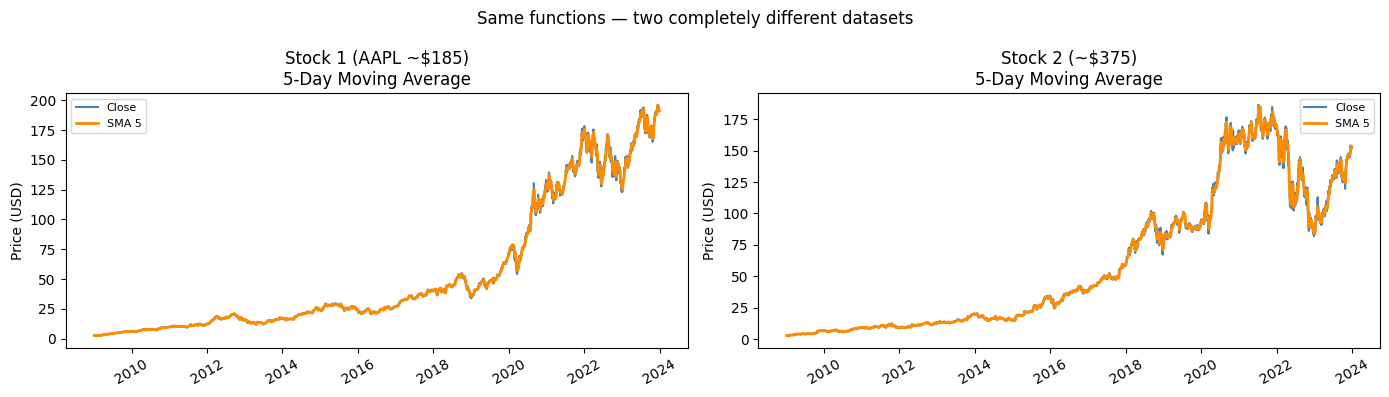


The same load_data(), remove_nulls(), compute_sma(), get_daily_return()
worked on both stocks without writing a single new line of logic.
THIS is why we write modular code.


In [53]:
# Compare both stocks side by side on the same chart
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, data, label in zip(axes, [df, df2], ['Stock 1 (AAPL ~$185)', 'Stock 2 (~$375)']):
    ax.plot(data.index, data['Close'],  label='Close',   color='steelblue', linewidth=1.5)
    ax.plot(data.index, data['SMA_5'],  label='SMA 5',   color='darkorange', linewidth=2)
    ax.set_title(f'{label}\n5-Day Moving Average')
    ax.set_ylabel('Price (USD)')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Same functions — two completely different datasets', fontsize=12)
plt.tight_layout()
plt.show()

print()
print('The same load_data(), remove_nulls(), compute_sma(), get_daily_return()')
print('worked on both stocks without writing a single new line of logic.')
print('THIS is why we write modular code.')

In [54]:
import talib

print(talib.__version__)

0.6.8
